#### The Tournament: Training Machine Learning Models and Comparing All to Find The Best Model.

##### The code below is only for Random Forest model. But we will use the below code where we did a tournament.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Load the model-ready dataset
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_Data_Final_Model_Ready.xlsx')

# 2. Select Features (X) and Target (y)
# Dropping non-predictive keys and the target itself
features_to_drop = ['Readmission_30D', 'Encounter_SK', 'Patient_FK', 'Provider_FK', 'Hospital_FK']
X = df.drop(columns=[c for c in df.columns if c in features_to_drop or 'Date' in c or 'SK' in c])
y = df['Readmission_30D']

# 3. Categorical Encoding
X = pd.get_dummies(X, drop_first=True)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Model Initialization & Training
# Using class_weight='balanced' to handle the 3.4% readmission minority
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = rf_model.predict(X_test)
print("--- Model Performance Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")

# 7. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Top 5 Predictive Features ---")
print(importances.head(5))

#### The Tournament Code 👇

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.impute import SimpleImputer

# 1. Load the model-ready dataset
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_Data_Final_Model_Ready.xlsx')

# 2. Strategic Pruning
df.columns = df.columns.str.strip()
target_col = 'Readmission_30D'

# Drop the "Leak" and administrative keys
hard_drops = [
    target_col, 'Encounter_SK', 'Patient_FK', 'Provider_FK', 'Hospital_FK', 
    'Diagnosis_FK', 'Zip_Code_Prefix', 'NPI_Number', 'Column2', 'Column3'
]

# Identify high-cardinality columns (>100 unique values) to drop
cols_to_drop = [col for col in df.columns if df[col].nunique() > 100 and col != target_col]

X = df.drop(columns=list(set(cols_to_drop + hard_drops)), errors='ignore')
y = df[target_col]

# 3. Handling NaNs with Safety Checks
numeric_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(exclude=['number']).columns

# Impute Numeric (Always exists)
imputer_num = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])

# Impute Categorical (ONLY if columns exist)
if len(categorical_cols) > 0:
    imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
    X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])
else:
    print("Note: No categorical columns found for imputation.")

# 4. One-Hot Encoding & Splitting
X = pd.get_dummies(X, drop_first=True)
print(f"Final Model Matrix: {X.shape[0]} rows and {X.shape[1]} features.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. The Real Tournament
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
print("\n--- Tournament in Progress (Leak-Proof & Robust) ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name, 
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4), 
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })

# 6. Final Validated Standings
tournament_table = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("\n", tournament_table)

##### Feature Importance from the winning Gradient Boosting model.

--- Top 15 Predictors (Gradient Boosting) ---
Acuity_Score                          0.477148
CCS_Category_Heart Failure            0.167506
Total_Bed_Count                       0.144471
Comorbidity_Weight                    0.102718
Trauma_Level                          0.040286
Site_Name_High Plains Rural Center    0.023942
State_Province_NE                     0.014379
City_Scottsbluff                      0.009939
Age_at_Encounter                      0.004064
Experience_Years                      0.001501
Length_of_Stay                        0.001114
Month_Name_Admit_October              0.000861
Quarter_Admit                         0.000736
Marital_Status_Married                0.000604
Total_Procedure_Count                 0.000599
dtype: float64


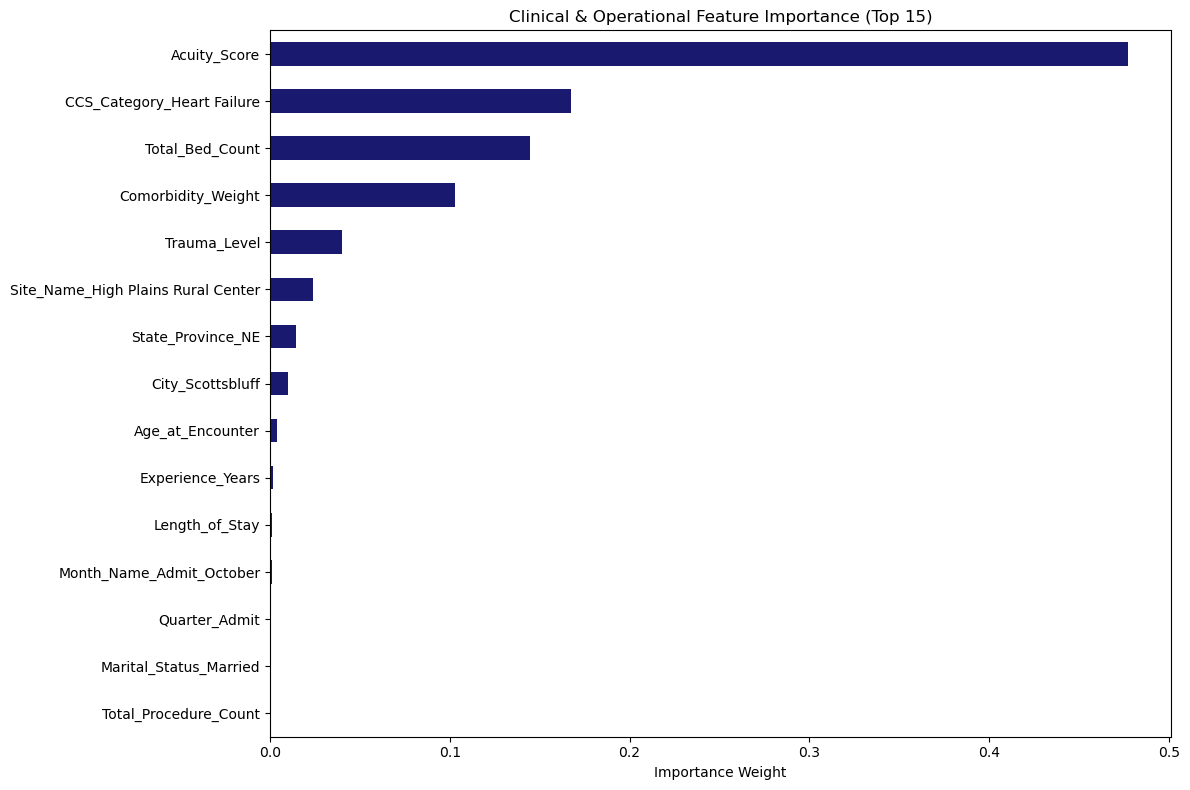

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract Feature Importance from the winning Gradient Boosting model
# (Assuming 'models' and 'X_train' are still in memory from the previous run)
gb_model = models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 2. Display the Top 15 Features
print("--- Top 15 Predictors (Gradient Boosting) ---")
print(importances.head(15))

# 3. Visualization for Executive Review
plt.figure(figsize=(12, 8))
importances.head(15).plot(kind='barh', color='midnightblue')
plt.title('Clinical & Operational Feature Importance (Top 15)')
plt.xlabel('Importance Weight')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### Model Serialization & Risk Export (.pkl file )

In [4]:
import pandas as pd
import joblib  # Standard library for saving .pkl files
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer

# 1. Setup paths and load data
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_Data_Final_Model_Ready.xlsx')

# 2. Final Feature Engineering (Matching our Leak-Proof Tournament)
target_col = 'Readmission_30D'
hard_drops = [target_col, 'Encounter_SK', 'Patient_FK', 'Provider_FK', 'Hospital_FK', 
              'Diagnosis_FK', 'Zip_Code_Prefix', 'NPI_Number', 'Column2', 'Column3']

# Cardinality filter (>100 unique values dropped)
cols_to_drop = [col for col in df.columns if df[col].nunique() > 100 and col != target_col]
X = df.drop(columns=list(set(cols_to_drop + hard_drops)), errors='ignore')
y = df[target_col]

# 3. Imputation (Handling NaNs)
numeric_cols = X.select_dtypes(include=['number']).columns
imputer_num = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])

# 4. Final Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Final Model Training (Crowned Champion: Gradient Boosting)
final_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
final_model.fit(X_encoded, y)

# 6. SAVE THE .PKL FILE
joblib.dump(final_model, path + 'final_readmission_model.pkl')
print("--- Success: final_readmission_model.pkl has been created ---")

# 7. Generate Risk Scores for Power BI
# We calculate the probability of '1' (Readmission) for every patient in the dataset
df['Readmission_Risk_Score'] = final_model.predict_proba(X_encoded)[:, 1]

# 8. Export Data for Dashboarding
# We keep key identifiers so Power BI can show which specific patients are high risk
cols_for_bi = ['Patient_FK', 'Encounter_SK', 'Acuity_Score', 'Readmission_30D', 'Readmission_Risk_Score']
df_for_bi = df[cols_for_bi]
df_for_bi.to_csv(path + 'Patient_Risk_Scores_for_PowerBI.csv', index=False)

print(f"--- Success: Patient_Risk_Scores_for_PowerBI.csv exported with {len(df)} records ---")

--- Success: final_readmission_model.pkl has been created ---
--- Success: Patient_Risk_Scores_for_PowerBI.csv exported with 89099 records ---
